## Sprint 1 — Análisis Exploratorio de Datos (EDA)
### RetailRocket Recommender System
**Equipo:** NexusDataCo | **Bootcamp:** SoyHenry Data Science  
**Dataset:** RetailRocket E-Commerce (Kaggle)  
**Objetivo:** Entender la estructura, calidad y distribuciones del dataset para guiar
las decisiones de modelado de los Sprints 2 y 3.

## 0. Configuración e Imports

In [24]:
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
from pathlib import Path
warnings.filterwarnings("ignore")

# Rutas a los datos
try:
    # Cuando se ejecuta como notebook en VS Code/Jupyter
    notebook_dir = Path(globals()["__vsc_ipynb_file__"]).parent
except KeyError:
    notebook_dir = Path().resolve()

ROOT     = notebook_dir.parent  # sube de notebooks/ a recommender-system/
DATA_RAW = ROOT / "data" / "raw"
DATA_PRO = ROOT / "data" / "processed"
os.chdir(ROOT)

# Estilo de gráficas 
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
COLORS = {
    "view":        "#378ADD",
    "addtocart":   "#EF9F27",
    "transaction": "#D85A30",
    "warm":        "#1D9E75",
    "cold":        "#534AB7",
    "neutral":     "#888780",
}
plt.rcParams.update({"figure.dpi": 120, "figure.figsize": (12, 5)})

print("** Configuración lista **")
print(f"   DATA_RAW: {DATA_RAW}")
print(f"   DATA_PRO: {DATA_PRO}")

** Configuración lista **
   DATA_RAW: d:\Work\Cursos\Data Science\Proyecto Final\recommender-system\data\raw
   DATA_PRO: d:\Work\Cursos\Data Science\Proyecto Final\recommender-system\data\processed


## 1. Carga del Dataset

In [25]:
print("Cargando events.csv...")
events = pd.read_csv(DATA_RAW / "events.csv")
events["datetime"] = pd.to_datetime(events["timestamp"], unit="ms")

print(f"\n{'='*50}")
print(f"EVENTS.CSV")
print(f"{'='*50}")
print(f"Shape:              {events.shape}")
print(f"Visitantes únicos:  {events['visitorid'].nunique():,}")
print(f"Ítems únicos:       {events['itemid'].nunique():,}")
print(f"Período:            {events['datetime'].min().date()} → {events['datetime'].max().date()}")
print(f"Días totales:       {(events['datetime'].max() - events['datetime'].min()).days}")
print(f"\nDtypes:\n{events.dtypes}")
print(f"\nPrimeras 5 filas:\n{events.head()}")

Cargando events.csv...

EVENTS.CSV
Shape:              (2756101, 6)
Visitantes únicos:  1,407,580
Ítems únicos:       235,061
Período:            2015-05-03 → 2015-09-18
Días totales:       137

Dtypes:
timestamp                 int64
visitorid                 int64
event                    object
itemid                    int64
transactionid           float64
datetime         datetime64[ns]
dtype: object

Primeras 5 filas:
       timestamp  visitorid event  itemid  transactionid  \
0  1433221332117     257597  view  355908            NaN   
1  1433224214164     992329  view  248676            NaN   
2  1433221999827     111016  view  318965            NaN   
3  1433221955914     483717  view  253185            NaN   
4  1433221337106     951259  view  367447            NaN   

                 datetime  
0 2015-06-02 05:02:12.117  
1 2015-06-02 05:50:14.164  
2 2015-06-02 05:13:19.827  
3 2015-06-02 05:12:35.914  
4 2015-06-02 05:02:17.106  


In [26]:
print("Cargando item_properties...")
props1 = pd.read_csv(DATA_RAW / "item_properties_part1.csv")
props2 = pd.read_csv(DATA_RAW / "item_properties_part2.csv")
props  = pd.concat([props1, props2], ignore_index=True)
props["datetime"] = pd.to_datetime(props["timestamp"], unit="ms")

print(f"\n{'='*50}")
print(f"ITEM_PROPERTIES (combinado)")
print(f"{'='*50}")
print(f"Shape:              {props.shape}")
print(f"  parte 1:          {props1.shape}")
print(f"  parte 2:          {props2.shape}")
print(f"Ítems únicos:       {props['itemid'].nunique():,}")
print(f"Propiedades únicas: {props['property'].nunique():,}")
print(f"\nPrimeras 5 filas:\n{props.head()}")

del props1, props2

Cargando item_properties...

ITEM_PROPERTIES (combinado)
Shape:              (20275902, 5)
  parte 1:          (10999999, 4)
  parte 2:          (9275903, 4)
Ítems únicos:       417,053
Propiedades únicas: 1,104

Primeras 5 filas:
       timestamp  itemid    property                            value  \
0  1435460400000  460429  categoryid                             1338   
1  1441508400000  206783         888          1116713 960601 n277.200   
2  1439089200000  395014         400  n552.000 639502 n720.000 424566   
3  1431226800000   59481         790                       n15360.000   
4  1431831600000  156781         917                           828513   

             datetime  
0 2015-06-28 03:00:00  
1 2015-09-06 03:00:00  
2 2015-08-09 03:00:00  
3 2015-05-10 03:00:00  
4 2015-05-17 03:00:00  


In [27]:
print("Cargando category_tree.csv...")
cat_tree = pd.read_csv(DATA_RAW / "category_tree.csv")
cat_tree["parentid"] = pd.to_numeric(cat_tree["parentid"], errors="coerce")

print(f"\n{'='*50}")
print(f"CATEGORY_TREE")
print(f"{'='*50}")
print(f"Shape:              {cat_tree.shape}")
print(f"Categorías raíz:    {cat_tree['parentid'].isna().sum()}")
print(f"Con padre:          {cat_tree['parentid'].notna().sum()}")
print(f"\nPrimeras 10 filas:\n{cat_tree.head(10)}")

Cargando category_tree.csv...

CATEGORY_TREE
Shape:              (1669, 2)
Categorías raíz:    25
Con padre:          1644

Primeras 10 filas:
   categoryid  parentid
0        1016     213.0
1         809     169.0
2         570       9.0
3        1691     885.0
4         536    1691.0
5         231       NaN
6         542     378.0
7        1146     542.0
8        1140     542.0
9        1479    1537.0


## 2. Calidad de Datos

### 2.1 Valores nulos

In [28]:
print("── Nulls por columna (events) ──────────────────────")
print(events.isnull().sum())
print(f"\nNota: transactionid tiene {events['transactionid'].isna().sum():,} nulls")
print("Esto es ESPERADO — solo los eventos 'transaction' tienen transactionid.")
print(f"Eventos transaction: {(events['event']=='transaction').sum():,}")

── Nulls por columna (events) ──────────────────────
timestamp              0
visitorid              0
event                  0
itemid                 0
transactionid    2733644
datetime               0
dtype: int64

Nota: transactionid tiene 2,733,644 nulls
Esto es ESPERADO — solo los eventos 'transaction' tienen transactionid.
Eventos transaction: 22,457


In [29]:
print("\n── Nulls por columna (item_properties) ──────────────")
print(props.isnull().sum())


── Nulls por columna (item_properties) ──────────────
timestamp    0
itemid       0
property     0
value        0
datetime     0
dtype: int64


### 2.2 Duplicados

In [30]:
dupes_events = events.duplicated(subset=["timestamp", "visitorid", "event", "itemid"]).sum()
dupes_props  = props.duplicated(subset=["itemid", "property", "value"]).sum()

print(f"Duplicados en events:          {dupes_events:,}  ({dupes_events/len(events)*100:.3f}%)")
print(f"Duplicados en item_properties: {dupes_props:,}  ({dupes_props/len(props)*100:.1f}%)")
print("\nAcción: eliminar duplicados exactos en el pipeline de limpieza.")

Duplicados en events:          460  (0.017%)
Duplicados en item_properties: 7,497,165  (37.0%)

Acción: eliminar duplicados exactos en el pipeline de limpieza.


### 2.3 Validación de transactionid

In [31]:
trans_events = events[events["event"] == "transaction"]
print(f"Eventos de tipo 'transaction':     {len(trans_events):,}")
print(f"Con transactionid nulo:            {trans_events['transactionid'].isna().sum():,}")
print(f"Con transactionid vacío (''):      {(trans_events['transactionid'] == '').sum():,}")
print(f"Transacciones únicas válidas:      {trans_events['transactionid'].nunique():,}")
print("\n Cero transactionid inválidos en eventos de compra.")

Eventos de tipo 'transaction':     22,457
Con transactionid nulo:            0
Con transactionid vacío (''):      0
Transacciones únicas válidas:      17,672

 Cero transactionid inválidos en eventos de compra.


### 2.4 Valores hasheados en item_properties

Valores con longitud > 20 chars (hasheados): 3,686,541 (18.2%)

Distribución de longitud de valores:
count    2.027590e+07
mean     1.765490e+01
std      3.747908e+01
min      1.000000e+00
25%      6.000000e+00
50%      7.000000e+00
75%      1.500000e+01
max      4.550000e+02
Name: val_len, dtype: float64

Ejemplos de valores cortos (legibles):
['1338' 'n15360.000' '828513' '0' '1121373' '319724' '1330310'
 'n21000.000' 'n5400.000' '1292080' '519769' '373898' 'n12.000' '1305767'
 'n60.000']

Ejemplos de valores largos (hasheados):
['1116713 960601 n277.200' 'n552.000 639502 n720.000 424566'
 '1038400 45956 n504.000'
 'n36.000 1186610 119932 717520 903287 98606 632686 1117759 504389 227411 768453 414047 1008741 561431 508431 621351 976840 260167 934278 388767 42948'
 'n480.000 639502 189174']

Decisión de diseño: usar hashes como features categóricas opacas en TF-IDF.


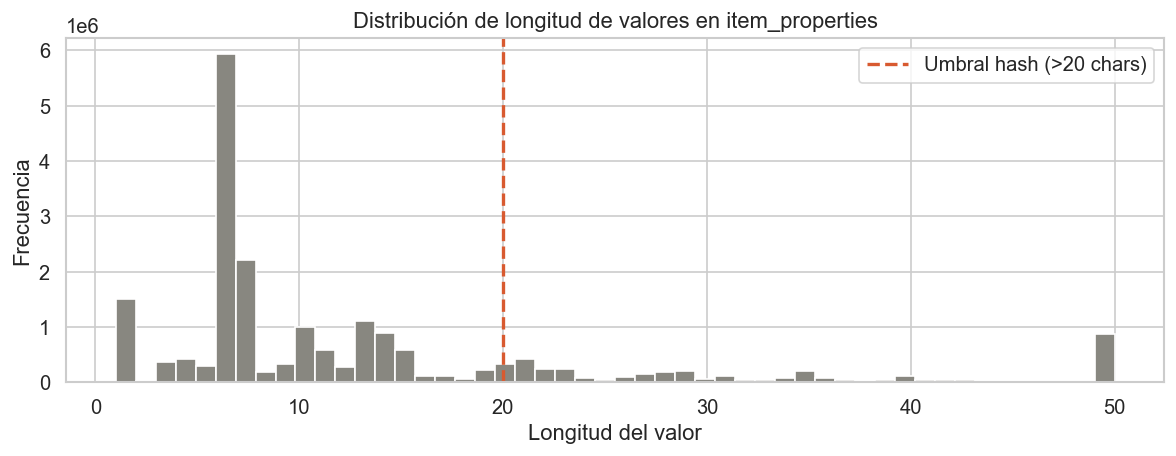

Gráfica guardada.


In [32]:
props["val_len"] = props["value"].astype(str).str.len()
n_hashed = (props["val_len"] > 20).sum()
pct_hashed = n_hashed / len(props) * 100

print(f"Valores con longitud > 20 chars (hasheados): {n_hashed:,} ({pct_hashed:.1f}%)")
print(f"\nDistribución de longitud de valores:")
print(props["val_len"].describe())
print(f"\nEjemplos de valores cortos (legibles):")
print(props[props["val_len"] <= 10]["value"].dropna().unique()[:15])
print(f"\nEjemplos de valores largos (hasheados):")
print(props[props["val_len"] > 20]["value"].dropna().unique()[:5])
print("\nDecisión de diseño: usar hashes como features categóricas opacas en TF-IDF.")

fig, ax = plt.subplots(figsize=(10, 4))
props["val_len"].clip(upper=50).hist(bins=50, ax=ax, color=COLORS["neutral"], edgecolor="white")
ax.axvline(20, color=COLORS["transaction"], linestyle="--", linewidth=2, label="Umbral hash (>20 chars)")
ax.set_xlabel("Longitud del valor")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribución de longitud de valores en item_properties")
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PRO / "eda_val_len_distribution.png", bbox_inches="tight")
plt.show()
print("Gráfica guardada.")

## 3. Análisis del Funnel de Conversión

### 3.1 Distribución de eventos

── Distribución de eventos ──────────────────────────
  view           :  2,664,312  (96.67%)
  addtocart      :     69,332  (2.52%)
  transaction    :     22,457  (0.81%)


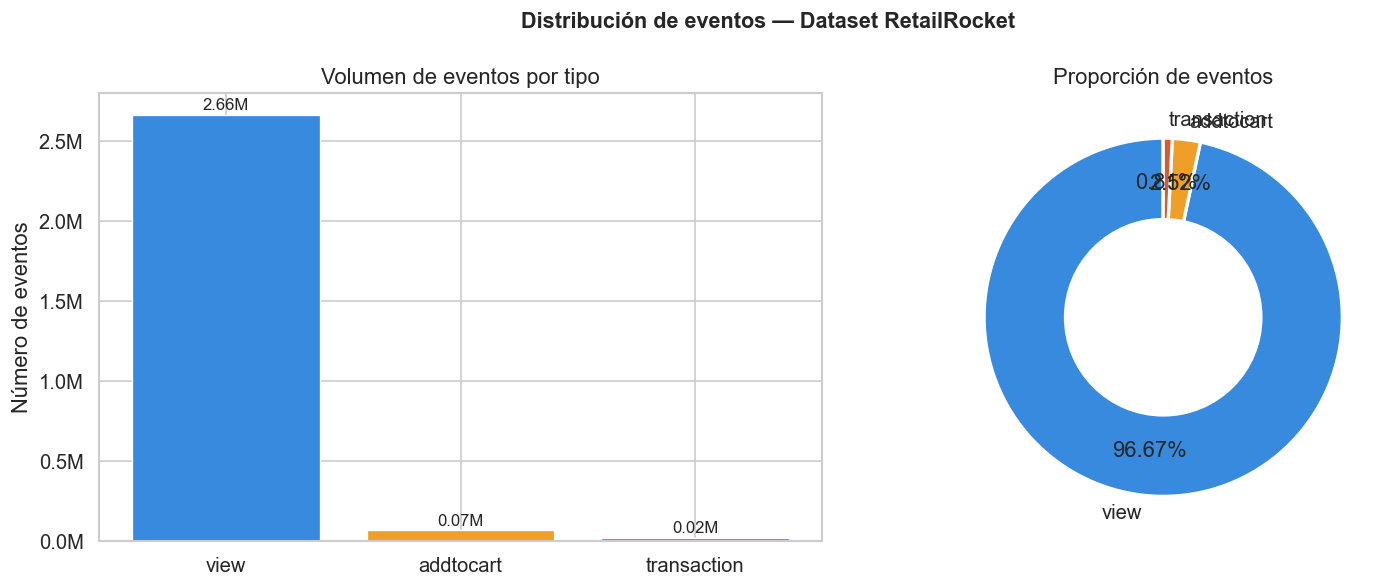

In [ ]:
event_counts = events["event"].value_counts()
event_pct    = events["event"].value_counts(normalize=True).mul(100).round(2)

print("── Distribución de eventos ──────────────────────────")
for evt in ["view", "addtocart", "transaction"]:
    print(f"  {evt:<15}: {event_counts[evt]:>10,}  ({event_pct[evt]:.2f}%)")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Barras
bars = axes[0].bar(
    event_counts.index,
    event_counts.values,
    color=[COLORS[e] for e in event_counts.index],
    edgecolor="white", linewidth=0.8
)
axes[0].set_title("Volumen de eventos por tipo")
axes[0].set_ylabel("Número de eventos")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
for bar, val in zip(bars, event_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10000,
                f"{val/1e6:.2f}M", ha="center", va="bottom", fontsize=10)

# Donut
wedge_colors = [COLORS[e] for e in event_counts.index]
wedges, texts, autotexts = axes[1].pie(
    event_counts.values,
    labels=event_counts.index,
    colors=wedge_colors,
    autopct="%1.2f%%",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    pctdistance=0.75,
)
centre_circle = plt.Circle((0, 0), 0.55, color="white")
axes[1].add_patch(centre_circle)
axes[1].set_title("Proporción de eventos")

plt.suptitle("Distribución de eventos — Dataset RetailRocket", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_PRO / "eda_event_distribution.png", bbox_inches="tight")
plt.show()

### 3.2 Funnel por usuarios únicos

── Funnel de conversión (usuarios únicos) ────────────
  Visitantes totales:      1,407,580  (100.00%)
  Vieron productos:        1,404,179  (99.76%)
  Agregaron al carrito:       37,722  (2.68%)
  Compraron:                  11,719  (0.8326%)

  Drop carrito→compra: 68.9% abandonó


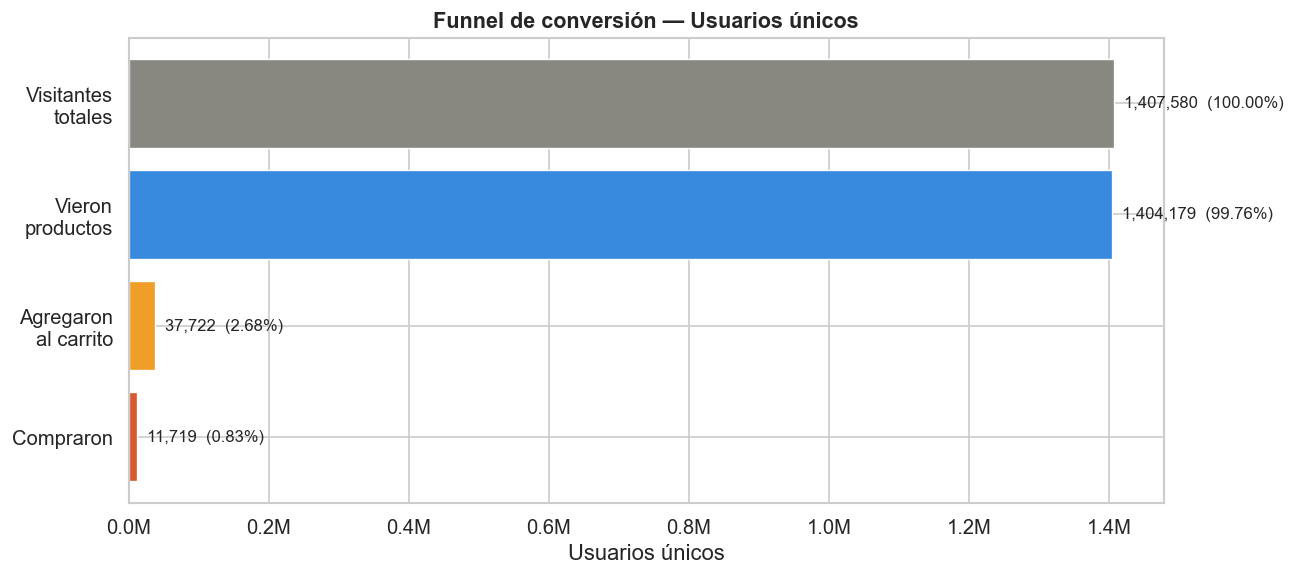

In [34]:
total_visitors = events["visitorid"].nunique()
viewers        = events[events["event"] == "view"]["visitorid"].nunique()
carters        = events[events["event"] == "addtocart"]["visitorid"].nunique()
buyers         = events[events["event"] == "transaction"]["visitorid"].nunique()

print("── Funnel de conversión (usuarios únicos) ────────────")
print(f"  Visitantes totales:     {total_visitors:>10,}  (100.00%)")
print(f"  Vieron productos:       {viewers:>10,}  ({viewers/total_visitors*100:.2f}%)")
print(f"  Agregaron al carrito:   {carters:>10,}  ({carters/total_visitors*100:.2f}%)")
print(f"  Compraron:              {buyers:>10,}  ({buyers/total_visitors*100:.4f}%)")
print(f"\n  Drop carrito→compra: {(1 - buyers/carters)*100:.1f}% abandonó")

funnel_labels  = ["Visitantes\ntotales", "Vieron\nproductos", "Agregaron\nal carrito", "Compraron"]
funnel_values  = [total_visitors, viewers, carters, buyers]
funnel_colors  = [COLORS["neutral"], COLORS["view"], COLORS["addtocart"], COLORS["transaction"]]

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(
    funnel_labels[::-1], funnel_values[::-1],
    color=funnel_colors[::-1], edgecolor="white", linewidth=0.8
)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M"))
ax.set_title("Funnel de conversión — Usuarios únicos", fontsize=13, fontweight="bold")
ax.set_xlabel("Usuarios únicos")

for bar, val, total in zip(bars, funnel_values[::-1], [total_visitors]*4):
    pct = val / total * 100
    ax.text(bar.get_width() + total_visitors * 0.01, bar.get_y() + bar.get_height()/2,
            f"{val:,}  ({pct:.2f}%)", va="center", fontsize=10)

plt.tight_layout()
plt.savefig(DATA_PRO / "eda_funnel_usuarios.png", bbox_inches="tight")
plt.show()

## 4. Análisis de Usuarios (Problema de Cold-Start)

### 4.1 Distribución de interacciones por usuario

In [35]:
user_counts = events.groupby("visitorid")["event"].count()

print("── Estadísticas de interacciones por usuario ────────")
print(user_counts.describe())
print(f"\nUsuarios con solo 1 evento:  {(user_counts == 1).sum():,}  ({(user_counts==1).mean()*100:.1f}%)")
print(f"Usuarios con 2 eventos:      {(user_counts == 2).sum():,}  ({(user_counts==2).mean()*100:.1f}%)")
print(f"Usuarios con >= 3 eventos:   {(user_counts >= 3).sum():,}  ({(user_counts>=3).mean()*100:.1f}%)")
print(f"Usuarios con >= 10 eventos:  {(user_counts >= 10).sum():,}  ({(user_counts>=10).mean()*100:.2f}%)")
print(f"Usuario más activo:          {user_counts.max():,} eventos")

── Estadísticas de interacciones por usuario ────────
count    1.407580e+06
mean     1.958042e+00
std      1.258049e+01
min      1.000000e+00
25%      1.000000e+00
50%      1.000000e+00
75%      2.000000e+00
max      7.757000e+03
Name: event, dtype: float64

Usuarios con solo 1 evento:  1,001,560  (71.2%)
Usuarios con 2 eventos:      205,992  (14.6%)
Usuarios con >= 3 eventos:   200,028  (14.2%)
Usuarios con >= 10 eventos:  23,241  (1.65%)
Usuario más activo:          7,757 eventos


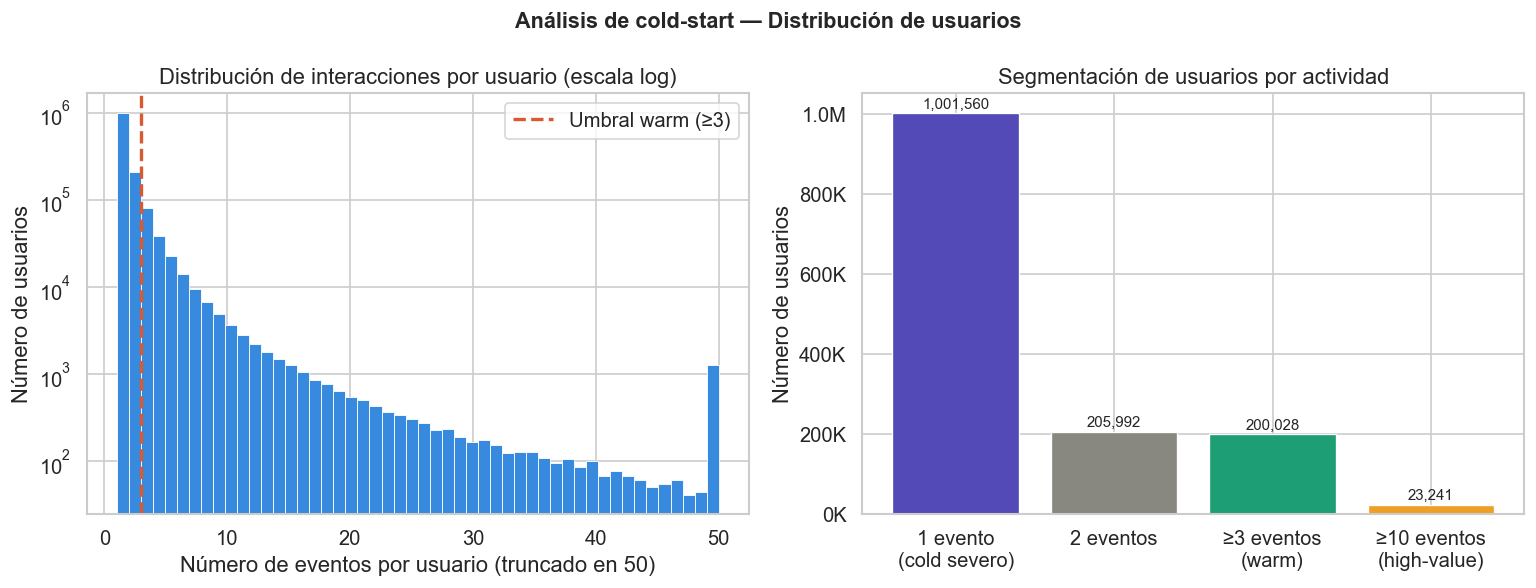

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Histograma — escala log
user_counts.clip(upper=50).hist(
    bins=50, ax=axes[0],
    color=COLORS["view"], edgecolor="white", linewidth=0.5
)
axes[0].set_xlabel("Número de eventos por usuario (truncado en 50)")
axes[0].set_ylabel("Número de usuarios")
axes[0].set_yscale("log")
axes[0].set_title("Distribución de interacciones por usuario (escala log)")
axes[0].axvline(3, color=COLORS["transaction"], linestyle="--",
                linewidth=2, label="Umbral warm (≥3)")
axes[0].legend()

# Barras de segmentos
segmentos  = ["1 evento\n(cold severo)", "2 eventos", "≥3 eventos\n(warm)", "≥10 eventos\n(high-value)"]
valores    = [
    (user_counts == 1).sum(),
    (user_counts == 2).sum(),
    (user_counts >= 3).sum(),
    (user_counts >= 10).sum(),
]
seg_colors = [COLORS["cold"], COLORS["neutral"], COLORS["warm"], COLORS["addtocart"]]

bars = axes[1].bar(segmentos, valores, color=seg_colors, edgecolor="white", linewidth=0.8)
axes[1].set_ylabel("Número de usuarios")
axes[1].set_title("Segmentación de usuarios por actividad")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))
for bar, val in zip(bars, valores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5000,
                f"{val:,}", ha="center", va="bottom", fontsize=9)

plt.suptitle("Análisis de cold-start — Distribución de usuarios", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_PRO / "eda_user_activity.png", bbox_inches="tight")
plt.show()

### 4.2 Curva de Lorenz — Sesgo de popularidad

── Sesgo de popularidad (Long-Tail) ────────────────
El 21.3% de los ítems concentra el 80% de las interacciones.
Top-10 ítems más vistos:
itemid
187946    3412
461686    2978
5411      2334
370653    1854
219512    1800
257040    1647
298009    1642
96924     1633
309778    1628
384302    1608
Name: event, dtype: int64


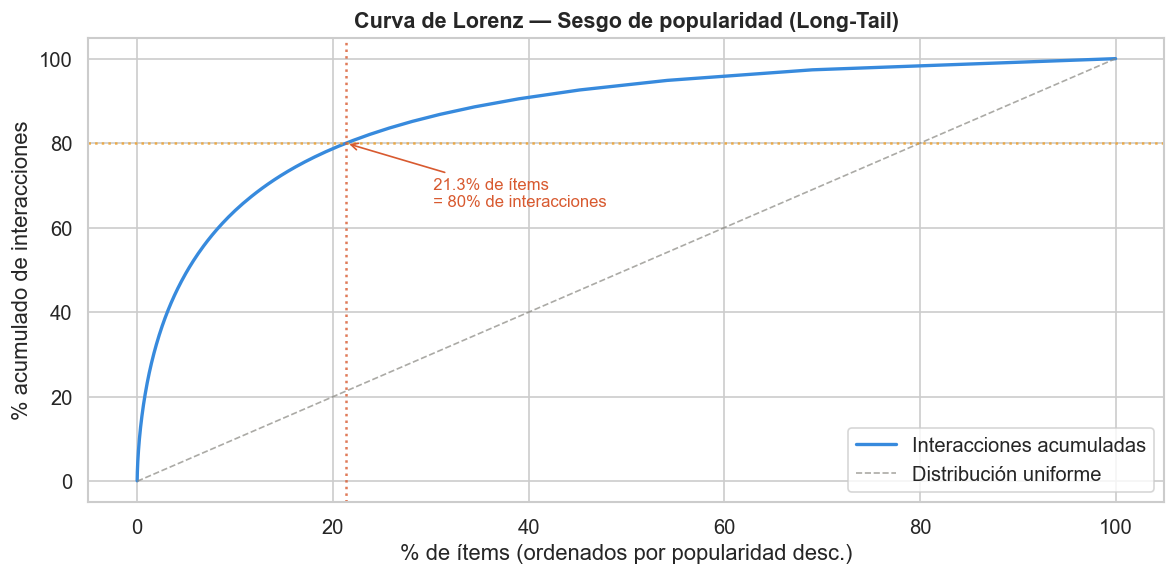

In [ ]:
item_interactions = events.groupby("itemid")["event"].count().sort_values(ascending=False)
cumsum = item_interactions.cumsum() / item_interactions.sum()
item_pct = np.linspace(0, 1, len(cumsum))

# ¿Qué % de ítems concentra el 80% de las interacciones?
idx_80 = np.searchsorted(cumsum.values, 0.80)
pct_items_80 = idx_80 / len(cumsum) * 100

print(f"── Sesgo de popularidad (Long-Tail) ────────────────")
print(f"El {pct_items_80:.1f}% de los ítems concentra el 80% de las interacciones.")
print(f"Top-10 ítems más vistos:")
print(item_interactions.head(10))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(item_pct * 100, cumsum.values * 100,
        color=COLORS["view"], linewidth=2, label="Interacciones acumuladas")
ax.plot([0, 100], [0, 100], "--", color=COLORS["neutral"],
        linewidth=1, alpha=0.7, label="Distribución uniforme")
ax.axhline(80, color=COLORS["addtocart"], linestyle=":", linewidth=1.5, alpha=0.8)
ax.axvline(pct_items_80, color=COLORS["transaction"], linestyle=":", linewidth=1.5, alpha=0.8)
ax.annotate(
        f"  {pct_items_80:.1f}% de ítems\n  = 80% de interacciones",
        xy=(pct_items_80, 80),
        xytext=(pct_items_80 + 8, 65),
        fontsize=10,
        arrowprops=dict(arrowstyle="->", color=COLORS["transaction"]),
        color=COLORS["transaction"],
)
ax.set_xlabel("% de ítems (ordenados por popularidad desc.)")
ax.set_ylabel("% acumulado de interacciones")
ax.set_title("Curva de Lorenz — Sesgo de popularidad (Long-Tail)", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(DATA_PRO / "eda_lorenz_popularidad.png", bbox_inches="tight")
plt.show()

## 5. Análisis Temporal

### 5.1 Eventos por día

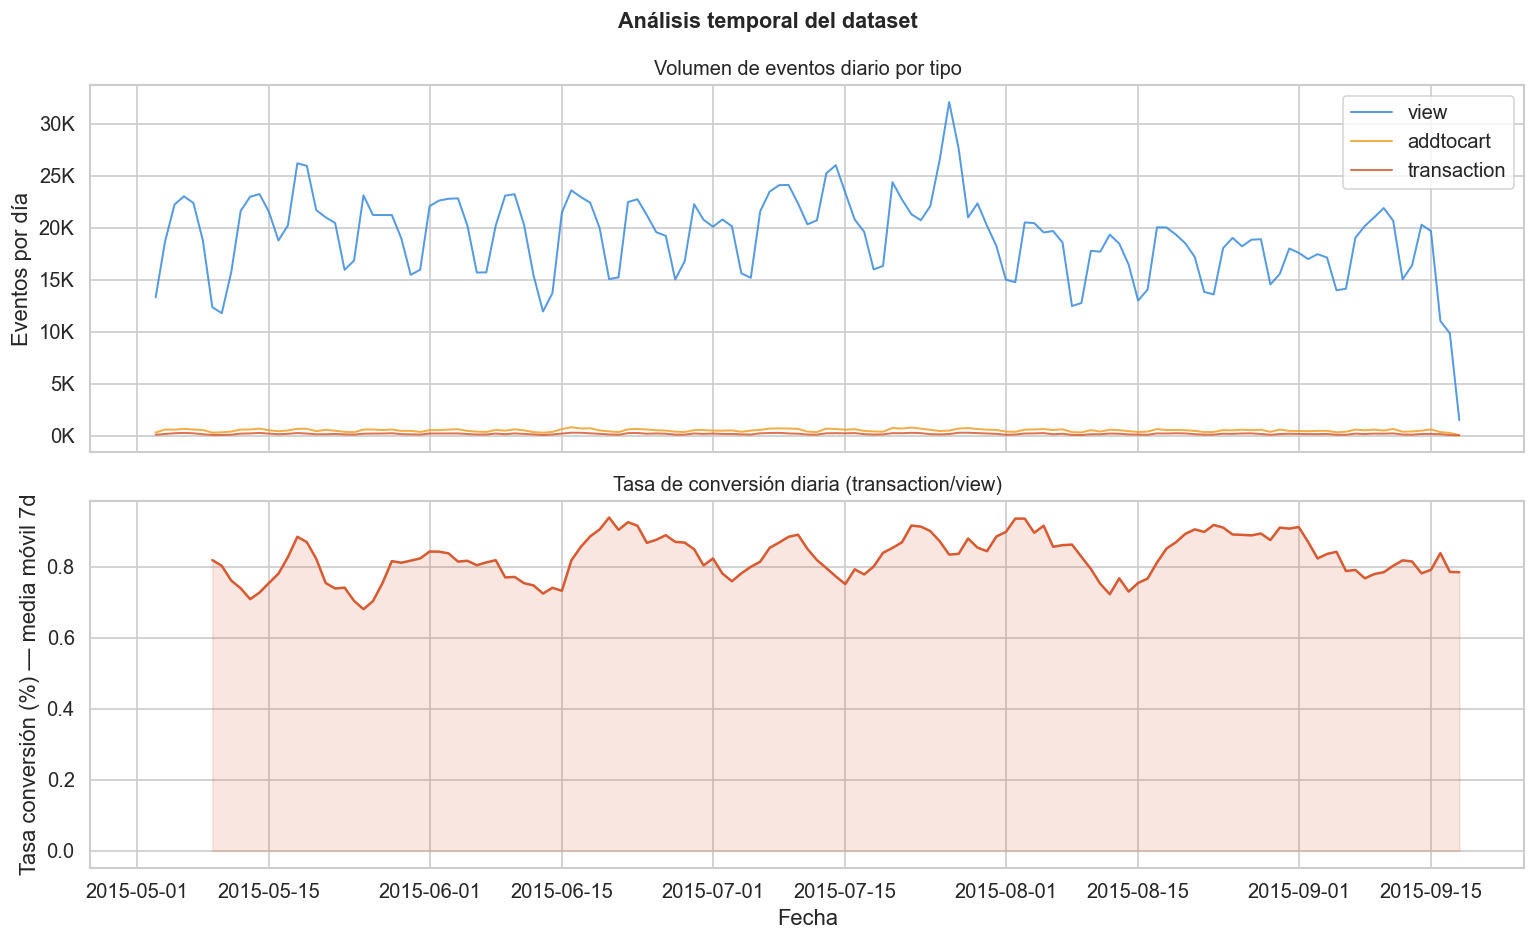

In [ ]:
events["date"] = events["datetime"].dt.date
daily_counts = events.groupby(["date", "event"])["visitorid"].count().reset_index()
daily_pivot  = daily_counts.pivot(index="date", columns="event", values="visitorid").fillna(0)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

for evt, color in [("view", COLORS["view"]),
                ("addtocart", COLORS["addtocart"]),
                ("transaction", COLORS["transaction"])]:
    if evt in daily_pivot.columns:
        axes[0].plot(daily_pivot.index, daily_pivot[evt],
                    label=evt, color=color, linewidth=1.2, alpha=0.85)

axes[0].set_ylabel("Eventos por día")
axes[0].set_title("Volumen de eventos diario por tipo", fontsize=12)
axes[0].legend()
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

# Tasa de conversión diaria
if "transaction" in daily_pivot.columns and "view" in daily_pivot.columns:
    daily_conv = (daily_pivot["transaction"] / daily_pivot["view"] * 100).rolling(7).mean()
    axes[1].plot(daily_conv.index, daily_conv.values,
                color=COLORS["transaction"], linewidth=1.5)
    axes[1].fill_between(daily_conv.index, daily_conv.values,
                        alpha=0.15, color=COLORS["transaction"])
    axes[1].set_ylabel("Tasa conversión (%) — media móvil 7d")
    axes[1].set_title("Tasa de conversión diaria (transaction/view)", fontsize=12)
    axes[1].set_xlabel("Fecha")

plt.suptitle("Análisis temporal del dataset", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_PRO / "eda_temporal_events.png", bbox_inches="tight")
plt.show()

### 5.2 Actividad por día de la semana y hora

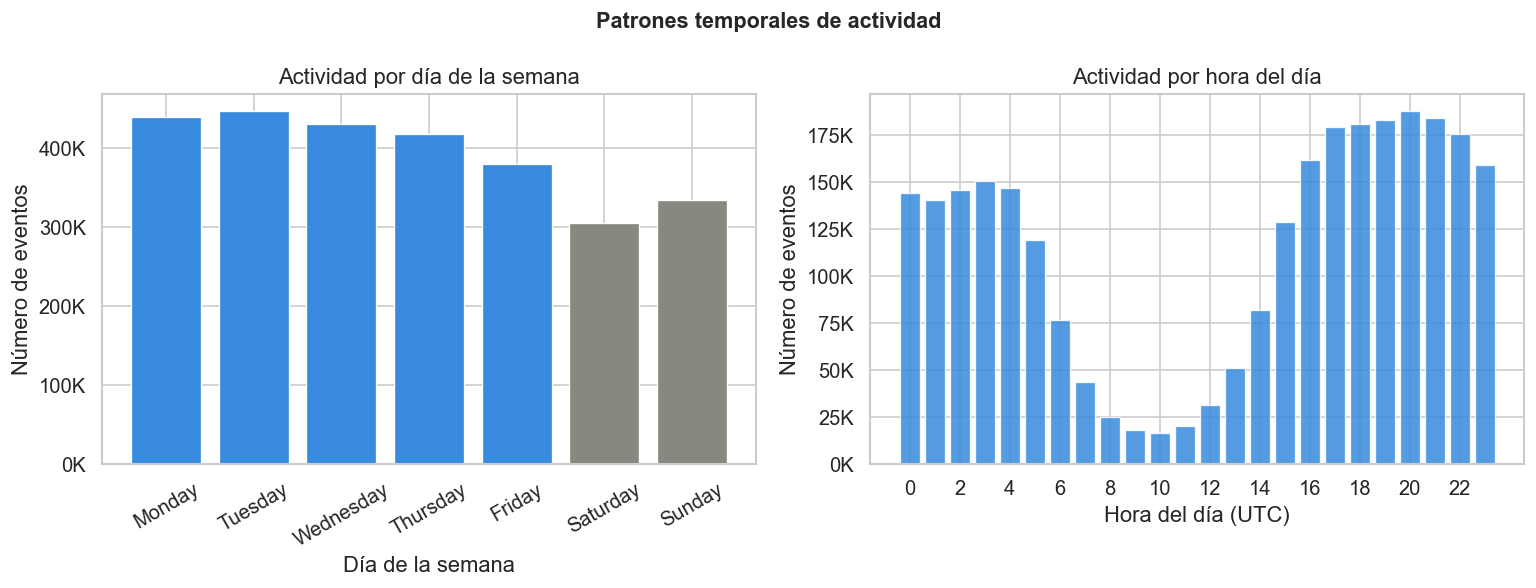

In [40]:
events["dow"]  = events["datetime"].dt.day_name()
events["hour"] = events["datetime"].dt.hour

dow_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dow_counts = events.groupby("dow")["event"].count().reindex(dow_order)
hour_counts = events.groupby("hour")["event"].count()

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].bar(dow_counts.index, dow_counts.values,
       color=[COLORS["view"] if d not in ["Saturday","Sunday"] else COLORS["neutral"]
              for d in dow_counts.index],
       edgecolor="white", linewidth=0.8)
axes[0].set_xlabel("Día de la semana")
axes[0].set_ylabel("Número de eventos")
axes[0].set_title("Actividad por día de la semana")
axes[0].tick_params(axis="x", rotation=30)
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

axes[1].bar(hour_counts.index, hour_counts.values,
       color=COLORS["view"], edgecolor="white", linewidth=0.8, alpha=0.85)
axes[1].set_xlabel("Hora del día (UTC)")
axes[1].set_ylabel("Número de eventos")
axes[1].set_title("Actividad por hora del día")
axes[1].set_xticks(range(0, 24, 2))
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

plt.suptitle("Patrones temporales de actividad", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_PRO / "eda_temporal_patterns.png", bbox_inches="tight")
plt.show()

## 6. Cobertura del Catálogo

── Cobertura del catálogo ───────────────────────────
Ítems en events:                  235,061
Ítems en item_properties:         417,053
Ítems en AMBOS (overlap):         185,246  → modelables CF + CBF
Solo en events (sin propiedades):  49,815  → solo CF
Solo en properties (sin eventos): 231,807  → catálogo invisible

55.6% del catálogo NUNCA recibió una interacción.
→ KPI de Coverage es crítico para activar estos ítems.


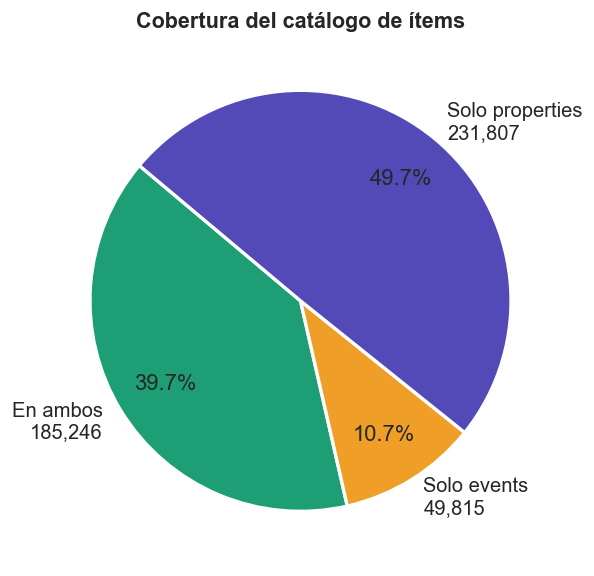

In [41]:
items_in_events = set(events["itemid"].unique())
items_in_props  = set(props["itemid"].unique())

overlap      = items_in_events & items_in_props
only_events  = items_in_events - items_in_props
only_props   = items_in_props  - items_in_events

print("── Cobertura del catálogo ───────────────────────────")
print(f"Ítems en events:                 {len(items_in_events):>8,}")
print(f"Ítems en item_properties:        {len(items_in_props):>8,}")
print(f"Ítems en AMBOS (overlap):        {len(overlap):>8,}  → modelables CF + CBF")
print(f"Solo en events (sin propiedades):{len(only_events):>8,}  → solo CF")
print(f"Solo en properties (sin eventos):{len(only_props):>8,}  → catálogo invisible")
print(f"\n{len(only_props)/len(items_in_props)*100:.1f}% del catálogo NUNCA recibió una interacción.")
print("→ KPI de Coverage es crítico para activar estos ítems.")

labels   = [f"En ambos\n{len(overlap):,}", f"Solo events\n{len(only_events):,}", f"Solo properties\n{len(only_props):,}"]
sizes    = [len(overlap), len(only_events), len(only_props)]
colors   = [COLORS["warm"], COLORS["addtocart"], COLORS["cold"]]

fig, ax = plt.subplots(figsize=(8, 5))
wedges, texts, autotexts = ax.pie(
    sizes, labels=labels, colors=colors,
    autopct="%1.1f%%", startangle=140,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    pctdistance=0.75,
)
ax.set_title("Cobertura del catálogo de ítems", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(DATA_PRO / "eda_catalog_coverage.png", bbox_inches="tight")
plt.show()

## 7. Análisis de item_properties

### 7.1 Top propiedades más frecuentes

── Top 20 propiedades ───────────────────────────────
property
888           3000398
790           1790516
available     1503639
categoryid     788214
6              631471
283            597419
776            574220
678            481966
364            476486
202            448938
839            417239
917            417227
764            417053
159            417053
112            417053
227            347492
698            289849
451            264416
663            240813
962            239372
Name: count, dtype: int64


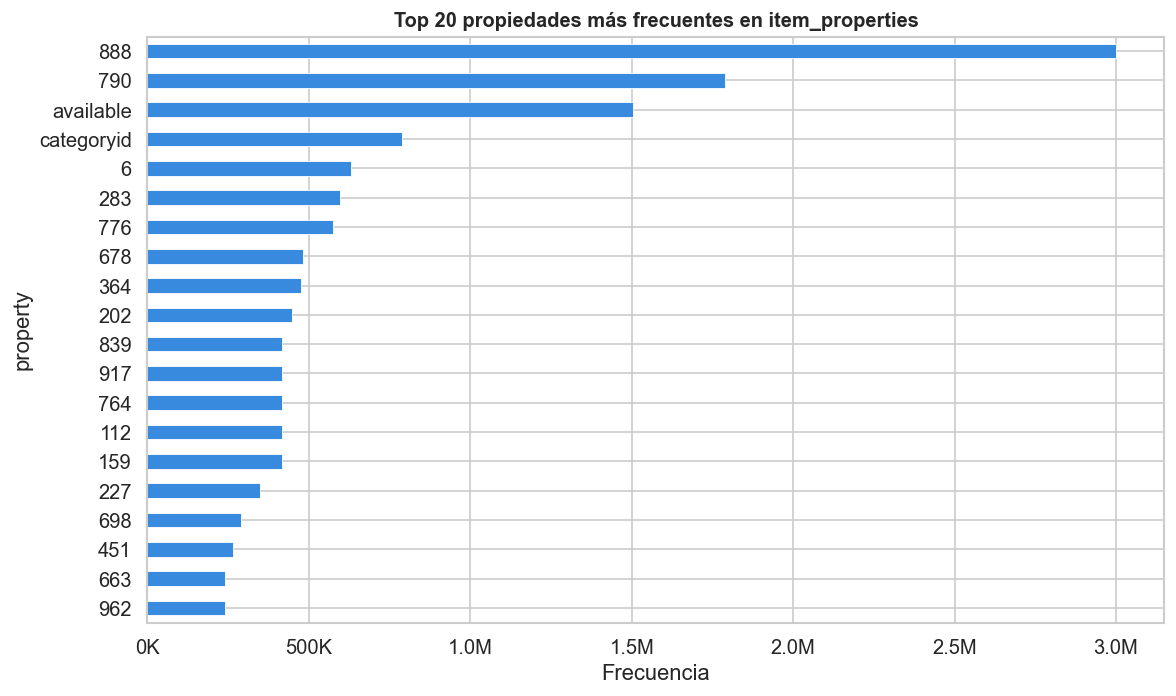

In [ ]:
top_props = props["property"].value_counts().head(20)
print("── Top 20 propiedades ───────────────────────────────")
print(top_props)

fig, ax = plt.subplots(figsize=(10, 6))
top_props.sort_values().plot(kind="barh", ax=ax,
                            color=COLORS["view"], edgecolor="white", linewidth=0.5)
ax.set_xlabel("Frecuencia")
ax.set_title("Top 20 propiedades más frecuentes en item_properties", fontsize=12, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K"))
plt.tight_layout()
plt.savefig(DATA_PRO / "eda_item_properties_top.png", bbox_inches="tight")
plt.show()

### 7.2 Categorías del catálogo

In [43]:
cat_props = props[props["property"] == "categoryid"]["value"].dropna()
print(f"Valores únicos de categoryid: {cat_props.nunique():,}")
print(f"Top 10 categorías por frecuencia de ítems:")
print(cat_props.value_counts().head(10))

Valores únicos de categoryid: 1,242
Top 10 categorías por frecuencia de ítems:
value
1147    26890
546     24885
1613    21126
491     19998
1404    18217
1120    18038
342     17231
1277    14990
1167    13509
282     11964
Name: count, dtype: int64


## 8. Árbol de Categorías

In [44]:
n_roots    = cat_tree["parentid"].isna().sum()
n_leaves   = cat_tree[~cat_tree["categoryid"].isin(cat_tree["parentid"].dropna())].shape[0]
n_children = cat_tree["parentid"].notna().sum()

print("── Estructura del árbol de categorías ──────────────")
print(f"Total nodos:        {len(cat_tree):,}")
print(f"Categorías raíz:    {n_roots}")
print(f"Categorías hoja:    {n_leaves}")
print(f"Nodos con padre:    {n_children}")

# Distribución de hijos por nodo padre
children_per_parent = cat_tree.groupby("parentid")["categoryid"].count()
print(f"\nHijos por nodo padre:")
print(children_per_parent.describe())
print(f"Nodo con más hijos: {children_per_parent.idxmax()} ({children_per_parent.max()} hijos)")

── Estructura del árbol de categorías ──────────────
Total nodos:        1,669
Categorías raíz:    25
Categorías hoja:    1307
Nodos con padre:    1644

Hijos por nodo padre:
count    362.000000
mean       4.541436
std        3.571152
min        1.000000
25%        2.000000
50%        4.000000
75%        6.000000
max       31.000000
Name: categoryid, dtype: float64
Nodo con más hijos: 250.0 (31 hijos)


## 9. Resumen Ejecutivo — Hallazgos para el Modelado

In [45]:
print("=" * 65)
print("RESUMEN EJECUTIVO — SPRINT 1")
print("=" * 65)

hallazgos = [
    ("CRÍTICO",   "Cold-start es el caso PRINCIPAL: 71.2% de usuarios tiene 1 solo evento."),
    ("CRÍTICO",   "55.5% del catálogo nunca fue visto → KPI Coverage es esencial."),
    ("CRÍTICO",   "Drop crítico: carrito→compra pierde 68.9% de usuarios con alta intención."),
    ("ATENCIÓN",  "Sesgo de popularidad severo: top 5% ítems = 80% de interacciones."),
    ("ATENCIÓN",  "18.2% de valores en item_properties son hashes → features categóricas."),
    ("POSITIVO",  "0 transactionid inválidos. Señal de compra limpia para ALS."),
    ("POSITIVO",  "460 duplicados eliminados (0.017%). Dataset muy limpio."),
    ("INSIGHT",   "185K ítems tienen eventos + propiedades → núcleo del modelo híbrido."),
    ("INSIGHT",   "1,242 categorías válidas → cold-start por categoría es viable."),
    ("INSIGHT",   "Lunes y martes concentran más tráfico. Fines de semana -30%."),
]

for tag, texto in hallazgos:
    emoji = {"CRÍTICO": "🔴", "ATENCIÓN": "🟡", "POSITIVO": "🟢", "INSIGHT": "🔵"}[tag]
    print(f"\n{emoji} [{tag}] {texto}")

print("\n" + "=" * 65)
print("ARTEFACTOS GENERADOS EN data/processed/:")
print("  eda_val_len_distribution.png")
print("  eda_event_distribution.png")
print("  eda_funnel_usuarios.png")
print("  eda_lorenz_popularidad.png")
print("  eda_temporal_events.png")
print("  eda_temporal_patterns.png")
print("  eda_catalog_coverage.png")
print("  eda_item_properties_top.png")
print("=" * 65)
print("EDA Sprint 1 completado.")

RESUMEN EJECUTIVO — SPRINT 1

🔴 [CRÍTICO] Cold-start es el caso PRINCIPAL: 71.2% de usuarios tiene 1 solo evento.

🔴 [CRÍTICO] 55.5% del catálogo nunca fue visto → KPI Coverage es esencial.

🔴 [CRÍTICO] Drop crítico: carrito→compra pierde 68.9% de usuarios con alta intención.

🟡 [ATENCIÓN] Sesgo de popularidad severo: top 5% ítems = 80% de interacciones.

🟡 [ATENCIÓN] 18.2% de valores en item_properties son hashes → features categóricas.

🟢 [POSITIVO] 0 transactionid inválidos. Señal de compra limpia para ALS.

🟢 [POSITIVO] 460 duplicados eliminados (0.017%). Dataset muy limpio.

🔵 [INSIGHT] 185K ítems tienen eventos + propiedades → núcleo del modelo híbrido.

🔵 [INSIGHT] 1,242 categorías válidas → cold-start por categoría es viable.

🔵 [INSIGHT] Lunes y martes concentran más tráfico. Fines de semana -30%.

ARTEFACTOS GENERADOS EN data/processed/:
  eda_val_len_distribution.png
  eda_event_distribution.png
  eda_funnel_usuarios.png
  eda_lorenz_popularidad.png
  eda_temporal_events.png